In [21]:
import pandas as pd
import os
import yfinance as yf
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression


In [23]:
parent_dir = os.path.dirname(os.getcwd())

In [25]:
df = pd.read_csv(parent_dir + '/data/sp500_stocks.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)
df.shape

(259073, 7)

In [26]:
df.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2005-01-03,0.947307,0.974548,0.936978,0.969608,691992000,AAPL
1,2005-01-04,0.957036,0.979936,0.942517,0.954790,1096810400,AAPL
2,2005-01-05,0.965418,0.976644,0.958682,0.964818,680433600,AAPL
3,2005-01-06,0.966166,0.971554,0.947905,0.967961,705555200,AAPL
4,2005-01-07,1.036514,1.042202,0.969159,0.972901,2227450400,AAPL


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 259073 entries, 0 to 259072
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   Date    259073 non-null  datetime64[us]
 1   Close   259073 non-null  float64       
 2   High    259073 non-null  float64       
 3   Low     259073 non-null  float64       
 4   Open    259073 non-null  float64       
 5   Volume  259073 non-null  int64         
 6   Ticker  259073 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 13.8 MB


In [28]:
df.iloc[259072,0]

Timestamp('2025-12-30 00:00:00')

In [29]:
print(f"Date range: {df.iloc[0,0]} to {df.iloc[259072,0]}")


Date range: 2005-01-03 00:00:00 to 2025-12-30 00:00:00


In [30]:
close_pivot = df.pivot_table(index='Date', columns='Ticker', values='Close')
log_return = np.log(close_pivot / close_pivot.shift(1)).dropna()
print(f"Log return stats:")
print(f"  Mean: {log_return.mean().mean():.6f}")
print(f"  Std: {log_return.std().mean():.6f}")
print(f"  Min: {log_return.min().min():.6f}")
print(f"  Max: {log_return.max().max():.6f}")

Log return stats:
  Mean: 0.000571
  Std: 0.017033
  Min: -0.432578
  Max: 0.352230


### We use log returns instead of simple returns because log returns are additive across time, while simple returns are not. This makes log returns better for statistical modelling and time-series analysis.

In [32]:
print("MISSING VALUES BY TICKER:")
missing_report = df.groupby('Ticker').agg({
    'Open': lambda x: x.isna().sum(),
    'High': lambda x: x.isna().sum(),
    'Low': lambda x: x.isna().sum(),
    'Close': lambda x: x.isna().sum(),
    'Volume': lambda x: x.isna().sum()
})

missing_report['Total_Missing'] = missing_report.sum(axis=1)
missing_report['Pct_Missing'] = (missing_report['Total_Missing'] / (len(df) / df['Ticker'].nunique())) * 100

print(missing_report[missing_report['Total_Missing'] > 0].sort_values('Total_Missing', ascending=False))
print("\n2. TRADING DAY GAPS ANALYSIS:")

def find_trading_gaps(df, ticker):
    ticker_df = df[df['Ticker'] == ticker].sort_values('Date')
    dates = ticker_df['Date']
    date_diff = dates.diff().dt.days
    gaps = date_diff[date_diff > 3]
    if len(gaps) > 0:
        gap_info = []
        for idx in gaps.index:
            gap_start = dates.iloc[date_diff.index.get_loc(idx) - 1]
            gap_end = dates.iloc[date_diff.index.get_loc(idx)]
            gap_days = gaps[idx]
            gap_info.append({
                'Start_Date': gap_start,
                'End_Date': gap_end,
                'Days_Missing': gap_days - 1
            })
        return pd.DataFrame(gap_info)
    else:
        return pd.DataFrame()

all_gaps = {}
for ticker in df['Ticker'].unique():
    gaps_df = find_trading_gaps(df, ticker)
    if len(gaps_df) > 0:
        all_gaps[ticker] = gaps_df

if all_gaps:
    print(f"\nTickers with trading gaps (>3 days): {len(all_gaps)}")
    for ticker, gaps in all_gaps.items():
        print(f"\n{ticker}: {len(gaps)} gaps found")
        print(f"  Largest gap: {gaps['Days_Missing'].max()} days")
        print(f"  Most recent gap: {gaps.iloc[-1]['End_Date'].date()}")
else:
    print("No significant trading gaps found (>3 days)")

MISSING VALUES BY TICKER:
Empty DataFrame
Columns: [Open, High, Low, Close, Volume, Total_Missing, Pct_Missing]
Index: []

2. TRADING DAY GAPS ANALYSIS:

Tickers with trading gaps (>3 days): 50

AAPL: 142 gaps found
  Largest gap: 4.0 days
  Most recent gap: 2025-09-02

ABBV: 87 gaps found
  Largest gap: 3.0 days
  Most recent gap: 2025-09-02

AMT: 142 gaps found
  Largest gap: 4.0 days
  Most recent gap: 2025-09-02

AMZN: 142 gaps found
  Largest gap: 4.0 days
  Most recent gap: 2025-09-02

APD: 142 gaps found
  Largest gap: 4.0 days
  Most recent gap: 2025-09-02

AVGO: 111 gaps found
  Largest gap: 4.0 days
  Most recent gap: 2025-09-02

AXP: 142 gaps found
  Largest gap: 4.0 days
  Most recent gap: 2025-09-02

BA: 142 gaps found
  Largest gap: 4.0 days
  Most recent gap: 2025-09-02

BAC: 142 gaps found
  Largest gap: 4.0 days
  Most recent gap: 2025-09-02

BLK: 142 gaps found
  Largest gap: 4.0 days
  Most recent gap: 2025-09-02

C: 142 gaps found
  Largest gap: 4.0 days
  Most rece

1. Weekends and Holidays (Normal Gaps):
  - These are not considered missing data
  - Markets are closed on weekends and holidays
  - We use forward fill (ffill) to carry forward prices through these gaps

2. Trading Halts (Intraday):
  - OHLCV data only shows end-of-day prices
  - Intraday halts are not visible in daily data
  - No special handling needed for daily analysis

3. Delistings / Bankruptcy:
  - Stock is removed from the dataset
  - We drop these stocks from our analysis
  - For modeling, we only use stocks with complete data

In [34]:
def compute_stock_statistics(returns_series, risk_free_rate=0.0):
    simple_returns = np.exp(returns_series) - 1
    
    annualized_return = returns_series.mean() * 252
    annualized_volatility = returns_series.std() * np.sqrt(252)
    
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility if annualized_volatility > 0 else 0
    
    cumulative = (1 + simple_returns).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()

    return {
        'annualized_return': annualized_return,
        'annualized_volatility': annualized_volatility,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown
    }

# Compute statistics for all stocks
stock_stats = {}

for ticker in log_return.columns:
    returns = log_return[ticker].dropna()
    if len(returns) > 100:  # Only include stocks with sufficient data
        stock_stats[ticker] = compute_stock_statistics(returns)

stats_df = pd.DataFrame(stock_stats).T
stats_df.index.name = 'Ticker'
stats_df = stats_df[['annualized_return', 'annualized_volatility', 'sharpe_ratio', 
                     'max_drawdown']]

# Format as percentages
stats_formatted = stats_df.copy()
for col in ['annualized_return', 'annualized_volatility', 'max_drawdown']:
    stats_formatted[col] = stats_formatted[col].apply(lambda x: f"{x:.2%}")
stats_formatted['sharpe_ratio'] = stats_formatted['sharpe_ratio'].apply(lambda x: f"{x:.3f}")

print("\nFull Statistics Summary:")
print(stats_formatted.round(4))

# Sort by Sharpe Ratio
sharpe_sorted = stats_df.sort_values('sharpe_ratio', ascending=False)

print("\nTOP 10 STOCKS BY SHARPE RATIO")
top_10 = sharpe_sorted.head(10)
print("\nTicker | Sharpe Ratio | Annual Return | Volatility | Max Drawdown")
print("-" * 70)
for ticker, row in top_10.iterrows():
    print(f"{ticker:6} |    {row['sharpe_ratio']:6.3f}    |   {row['annualized_return']:8.2%}    |  {row['annualized_volatility']:8.2%}  |  {row['max_drawdown']:8.2%}")
    
print("\nBOTTOM 10 STOCKS BY SHARPE RATIO")

bottom_10 = sharpe_sorted.tail(10)
print("\nTicker | Sharpe Ratio | Annual Return | Volatility | Max Drawdown")
print("-" * 70)
for ticker, row in bottom_10.iterrows():
    print(f"{ticker:6} |    {row['sharpe_ratio']:6.3f}    |   {row['annualized_return']:8.2%}    |  {row['annualized_volatility']:8.2%}  |  {row['max_drawdown']:8.2%}")



Full Statistics Summary:
       annualized_return annualized_volatility sharpe_ratio max_drawdown
Ticker                                                                  
AAPL              21.59%                28.33%        0.762      -38.52%
ABBV              18.49%                26.48%        0.698      -45.09%
AMT                8.47%                24.45%        0.347      -45.34%
AMZN              22.32%                32.39%        0.689      -56.15%
APD               11.22%                24.78%        0.453      -31.77%
AVGO              38.52%                37.84%        1.018      -48.30%
AXP               15.63%                29.11%        0.537      -49.64%
BA                 9.40%                37.76%        0.249      -77.92%
BAC               13.62%                29.61%        0.460      -48.95%
BLK               15.04%                26.49%        0.568      -43.90%
C                 10.34%                31.30%        0.330      -56.51%
CAT               16.57% 

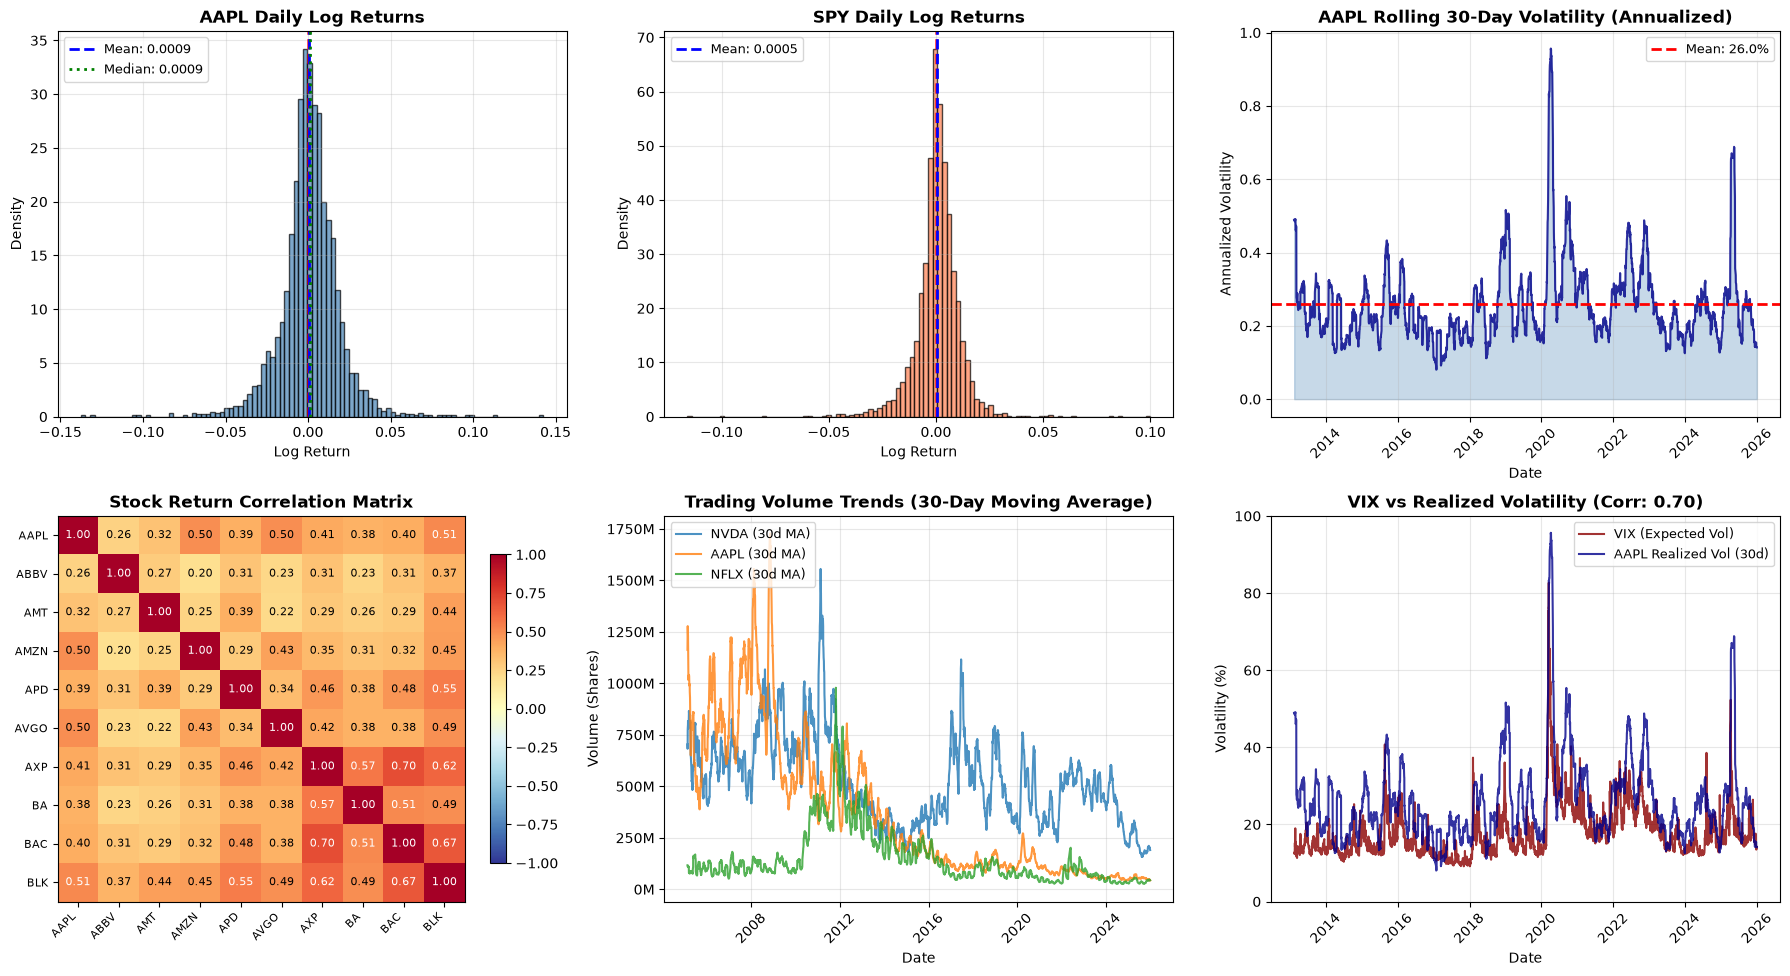

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

tickers_list = log_return.columns.tolist()
first_ticker = tickers_list[0]

# APPL Daily Returns
stock_returns = log_return[first_ticker].dropna()
axes[0, 0].hist(stock_returns, bins=100, alpha=0.7, edgecolor='black', density=True, color='steelblue')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[0, 0].axvline(x=stock_returns.mean(), color='blue', linestyle='--', linewidth=2, 
                   label=f'Mean: {stock_returns.mean():.4f}')
axes[0, 0].axvline(x=stock_returns.median(), color='green', linestyle=':', linewidth=2,
                   label=f'Median: {stock_returns.median():.4f}')
axes[0, 0].set_title(f'{first_ticker} Daily Log Returns', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Log Return')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend(loc='upper left', fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# SPY Daily Returns
spy_returns = log_return['SPY'].dropna()
axes[0, 1].hist(spy_returns, bins=100, alpha=0.7, edgecolor='black', density=True, color='coral')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[0, 1].axvline(x=spy_returns.mean(), color='blue', linestyle='--', linewidth=2, 
                   label=f'Mean: {spy_returns.mean():.4f}')
axes[0, 1].set_title('SPY Daily Log Returns', fontsize=12, fontweight='bold')
second_label = 'SPY'

axes[0, 1].set_xlabel('Log Return')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend(loc='upper left', fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# Rolling 30-Day Volatility
rolling_vol_aapl = log_return['AAPL'].rolling(window=30).std() * np.sqrt(252)

axes[0, 2].plot(rolling_vol_aapl.index, rolling_vol_aapl.values, 
                color='darkblue', linewidth=1.5, alpha=0.8)
axes[0, 2].fill_between(rolling_vol_aapl.index, 0, rolling_vol_aapl.values, 
                        alpha=0.3, color='steelblue')
axes[0, 2].axhline(y=rolling_vol_aapl.mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {rolling_vol_aapl.mean():.1%}')
axes[0, 2].set_title('AAPL Rolling 30-Day Volatility (Annualized)', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Date', fontsize=10)
axes[0, 2].set_ylabel('Annualized Volatility', fontsize=10)
axes[0, 2].legend(loc='upper right', fontsize=9)
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].tick_params(axis='x', rotation=45)

# Corellation Heatmap

stocks_to_show = tickers_list[:min(10, len(tickers_list))]
corr_matrix = log_return[stocks_to_show].corr()
im = axes[1, 0].imshow(corr_matrix, cmap='RdYlBu_r', aspect='auto', vmin=-1, vmax=1)
axes[1, 0].set_xticks(np.arange(len(stocks_to_show)))
axes[1, 0].set_yticks(np.arange(len(stocks_to_show)))
axes[1, 0].set_xticklabels(stocks_to_show, rotation=45, ha='right', fontsize=8)
axes[1, 0].set_yticklabels(stocks_to_show, fontsize=8)
axes[1, 0].set_title('Stock Return Correlation Matrix', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axes[1, 0], shrink=0.8)
for i in range(len(stocks_to_show)):
    for j in range(len(stocks_to_show)):
        text_color = 'white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black'
        axes[1, 0].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                        ha="center", va="center", color=text_color, fontsize=8)

# Volume Trend
volume_data = df.groupby('Ticker')['Volume'].mean().sort_values(ascending=False).head(3)

for ticker in volume_data.index:
    ticker_volume = df[df['Ticker'] == ticker].sort_values('Date')
    
    rolling_volume = ticker_volume['Volume'].rolling(window=30).mean()
    
    axes[1, 1].plot(ticker_volume['Date'], rolling_volume, 
                    label=f'{ticker} (30d MA)', linewidth=1.5, alpha=0.8)

axes[1, 1].set_title('Trading Volume Trends (30-Day Moving Average)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Date', fontsize=10)
axes[1, 1].set_ylabel('Volume (Shares)', fontsize=10)
axes[1, 1].legend(loc='upper left', fontsize=9)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))


# Vix vs Realized Volatility
vix = yf.download('^VIX', start=log_return.index.min(), end=log_return.index.max(), progress=False)

vix_aligned = vix['Close'].reindex(log_return.index)
vix_aligned = vix_aligned.ffill()

realized_vol = log_return['AAPL'].rolling(window=30).std() * np.sqrt(252)*100

combined = pd.DataFrame({
    'VIX': vix_aligned.values.ravel(), 
    'Realized': realized_vol.values.ravel() 
}, index=log_return.index).dropna()

axes[1, 2].clear()
axes[1, 2].plot(combined.index, combined['VIX'], label='VIX (Expected Vol)', 
                color='darkred', linewidth=1.5, alpha=0.8)
axes[1, 2].plot(combined.index, combined['Realized'], label='AAPL Realized Vol (30d)', 
                color='darkblue', linewidth=1.5, alpha=0.8)
correlation = combined['VIX'].corr(combined['Realized'])
axes[1, 2].set_title(f'VIX vs Realized Volatility (Corr: {correlation:.2f})', 
                     fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Date', fontsize=10)
axes[1, 2].set_ylabel('Volatility (%)', fontsize=10)
axes[1, 2].legend(loc='upper right', fontsize=9)
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].set_ylim(bottom=0)

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.savefig('financial_distribution_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

Rolling correlation calculated:
  Shape: (3209,)
  Date range: 2013-04-01 to 2025-12-30
  Mean correlation: 0.6194
  Min correlation: 0.0424
  Max correlation: 0.9570


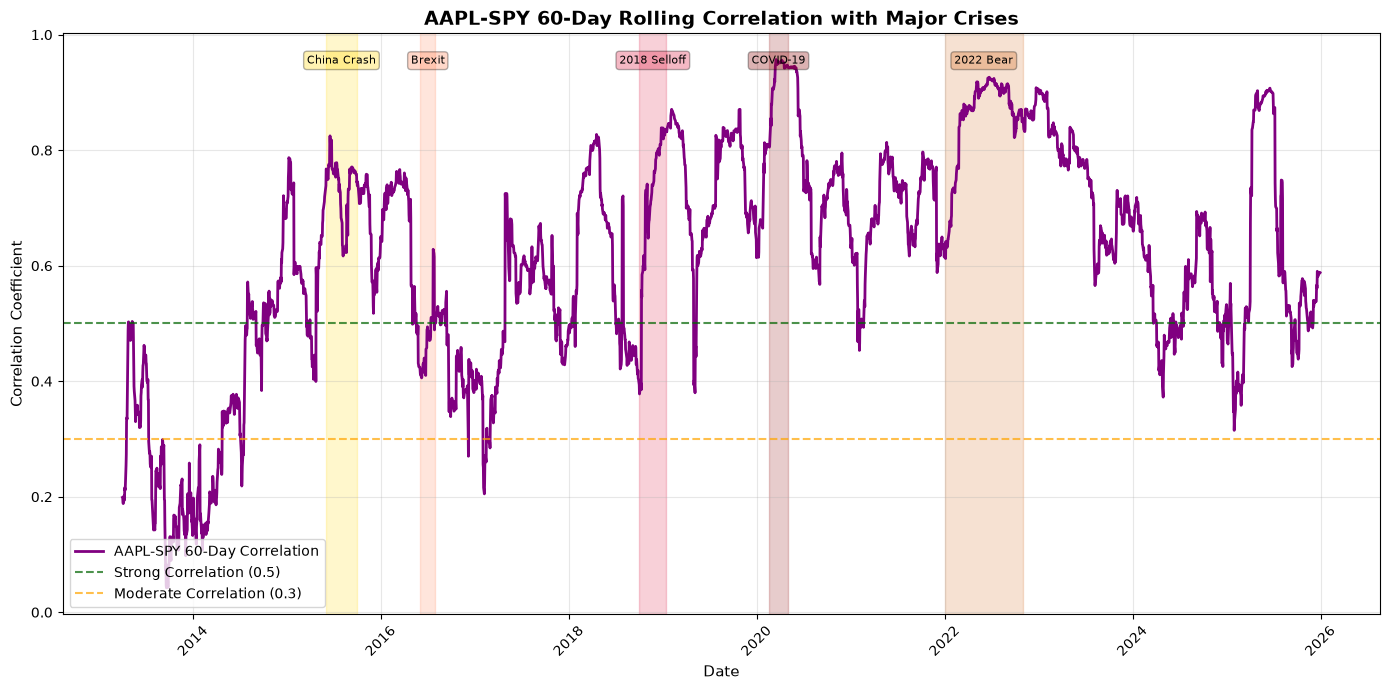

In [41]:
close_pivot = df.pivot_table(index='Date', columns='Ticker', values='Close')
log_returns = np.log(close_pivot / close_pivot.shift(1)).dropna()
rolling_corr_60 = log_returns['AAPL'].rolling(window=60).corr(log_returns['SPY'])
rolling_corr_60 = rolling_corr_60.dropna()

print(f"Rolling correlation calculated:")
print(f"  Shape: {rolling_corr_60.shape}")
print(f"  Date range: {rolling_corr_60.index[0].date()} to {rolling_corr_60.index[-1].date()}")
print(f"  Mean correlation: {rolling_corr_60.mean():.4f}")
print(f"  Min correlation: {rolling_corr_60.min():.4f}")
print(f"  Max correlation: {rolling_corr_60.max():.4f}")

fig, ax = plt.subplots(figsize=(14, 7))

# Plot correlation
ax.plot(rolling_corr_60.index, rolling_corr_60.values, 
        color='purple', linewidth=2, label='AAPL-SPY 60-Day Correlation')

# Add all crisis periods
crisis_periods = [
    ('2008 Crisis', '2008-08-01', '2009-04-30'),
    ('Euro Crisis', '2011-07-01', '2011-10-31'),
    ('China Crash', '2015-06-01', '2015-09-30'),
    ('Brexit', '2016-06-01', '2016-07-31'),
    ('2018 Selloff', '2018-10-01', '2019-01-15'),
    ('COVID-19', '2020-02-19', '2020-04-30'),
    ('2022 Bear', '2022-01-01', '2022-10-31')
]

colors = ['red', 'orange', 'gold', 'coral', 'crimson', 'darkred', 'chocolate']

for i, (label, start, end) in enumerate(crisis_periods):
    start_date = pd.to_datetime(start)
    end_date = pd.to_datetime(end)
    
    # Only plot if within data range
    if start_date <= rolling_corr_60.index.max() and end_date >= rolling_corr_60.index.min():
        ax.axvspan(start_date, end_date, alpha=0.2, color=colors[i % len(colors)])
        # Add label
        mid_date = start_date + (end_date - start_date) / 2
        if mid_date <= rolling_corr_60.index.max():
            ax.text(mid_date, 0.95, label, ha='center', fontsize=8, rotation=0,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[i % len(colors)], alpha=0.3))

# Add reference lines
ax.axhline(y=0.5, color='darkgreen', linestyle='--', alpha=0.7, label='Strong Correlation (0.5)')
ax.axhline(y=0.3, color='orange', linestyle='--', alpha=0.7, label='Moderate Correlation (0.3)')

ax.set_title('AAPL-SPY 60-Day Rolling Correlation with Major Crises', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Correlation Coefficient', fontsize=11)
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('aapl_spy_correlation_crises.png', dpi=300, bbox_inches='tight')
plt.show()

### From this graph, we can see that there is an increased correlation during Market Crashes since investors would:
- Panic and sell everything indiscriminately/move to cash
- Reduce risk exposure across all assets

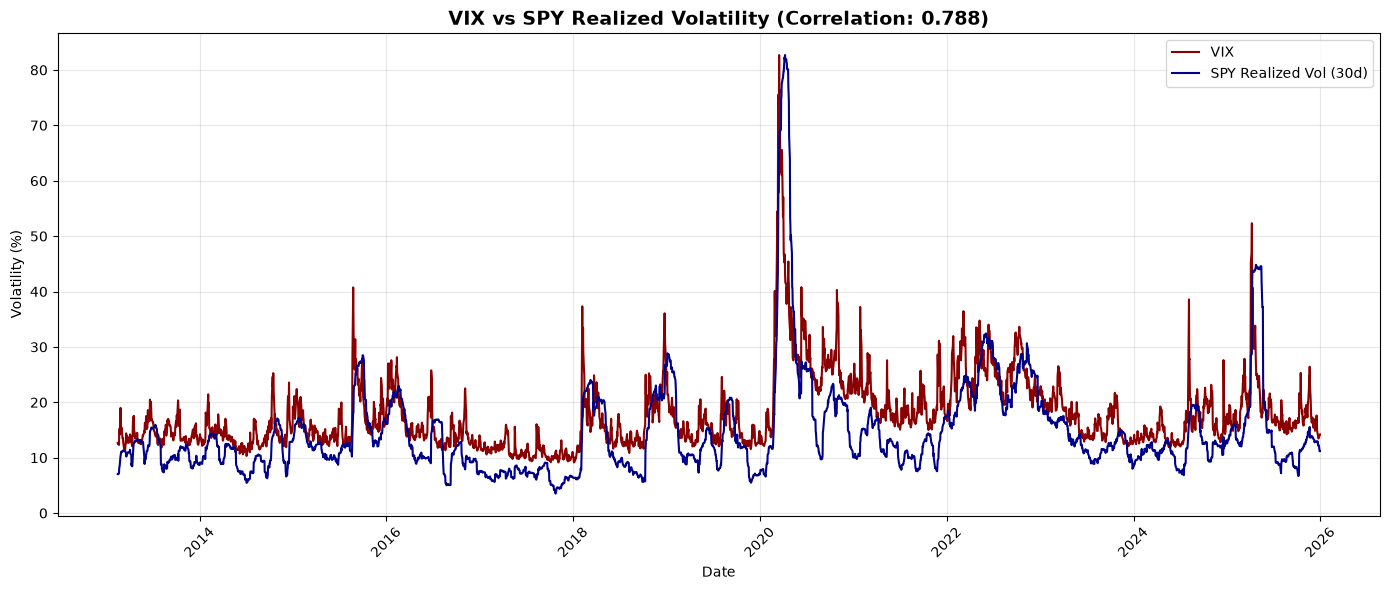

VIX vs Realized Volatility Correlation: 0.788


In [43]:
vix = yf.download('^VIX', start=log_return.index.min(), end=log_return.index.max(), progress=False)
vix_aligned = vix['Close'].reindex(log_return.index).ffill()
spy_realized_vol = log_return['SPY'].rolling(window=30).std() * np.sqrt(252) * 100

vix_df = pd.DataFrame({
    'VIX': vix_aligned.values.ravel(),
    'Realized_Vol': spy_realized_vol.values.ravel()
}, index=log_return.index).dropna()

# plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(vix_df.index, vix_df['VIX'], label='VIX', color='darkred', linewidth=1.5)
ax.plot(vix_df.index, vix_df['Realized_Vol'], label='SPY Realized Vol (30d)', color='darkblue', linewidth=1.5)

# Calculate correlation
corr = vix_df['VIX'].corr(vix_df['Realized_Vol'])
ax.set_title(f'VIX vs SPY Realized Volatility (Correlation: {corr:.3f})', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (%)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('vix_vs_realized_volatility_simple.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"VIX vs Realized Volatility Correlation: {corr:.3f}")

### The VIX is a good predictor of future volatility, particularly for the short term (up to 30 days), but it's not perfect. The correlation between VIX and forward realized volatility typically ranges from 0.5 to 0.7, indicating strong predictive power.